[*********************100%***********************]  1 of 1 completed

Date
2020-01-03   -0.001176
2020-01-06   -0.015478
2020-01-07   -0.003076
2020-01-08   -0.003600
2020-01-09    0.011698
Name: HSBA.L, dtype: float64


<Axes: xlabel='Date'>

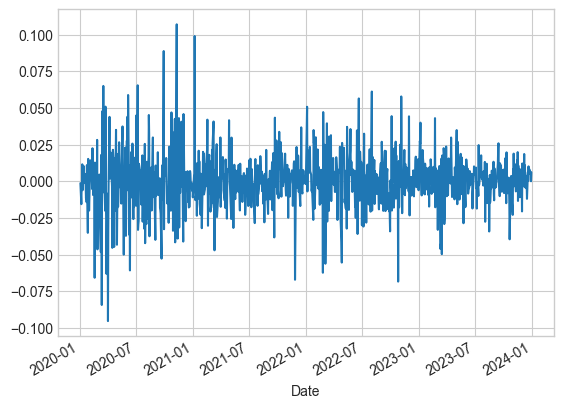

In [32]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Download historical data for HSBC Holdings plc (HSBA.L) from Yahoo Finance
data = yf.download("HSBA.L", start="2020-01-01", end="2024-01-01")
returns = data["Close"].squeeze().pct_change().dropna()
# Display the first few rows of the returns and plot them
print(returns.head())
returns.plot()

In [33]:
# Value at Risk (VaR) calculations
import numpy as np
from scipy.stats import norm

# Historical VaR
def historical_var(returns, confidence = 0.99):
    return np.percentile(returns.dropna(), (1 - confidence) * 100)

# Parametric VaR
def parametric_var(returns, confidence = 0.99):
    mu = returns.mean()
    sigma = returns.std()
    return mu - sigma * norm.ppf(confidence)

In [34]:
portfolio_value = 10000 

h_var = historical_var(returns)
p_var = parametric_var(returns)

print(f"Portfolio value: £{portfolio_value:,.2f}")
print(f"Historical 99%: {h_var:.4f} → £{abs(h_var) * portfolio_value:,.2f}")
print(f"Parametric 99%: {p_var:.4f} → £{abs(p_var) * portfolio_value:,.2f}")

Portfolio value: £10,000.00
Historical 99%: -0.0525 → £524.67
Parametric 99%: -0.0441 → £440.60


In [35]:
def plot_daily_returns(returns):
    plt.style.use("seaborn-v0_8-whitegrid")
    fig, ax = plt.subplots(figsize=(12, 5))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    positive = returns.copy()
    negative = returns.copy()
    positive[positive < 0] = 0
    negative[negative > 0] = 0

    ax.bar(returns.index, positive, color="#1565C0", alpha=0.7, width=1, label="Positive return")
    ax.bar(returns.index, negative, color="#B71C1C", alpha=0.7, width=1, label="Negative return")

    ax.axhline(0, color="#555555", linewidth=0.8, zorder=3)
    ax.axhline(h_var, color="#B71C1C", linestyle="--", linewidth=1, 
               label=f"Historical VaR 99%: {h_var:.2%}", zorder=4)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#CCCCCC")
    ax.spines["bottom"].set_color("#CCCCCC")
    ax.yaxis.grid(True, color="#EEEEEE", linewidth=0.8, zorder=0)
    ax.xaxis.grid(False)

    ax.set_title("HSBC Daily Returns", fontsize=13, fontweight="bold", pad=15, loc="left")
    ax.set_xlabel("Date", fontsize=10, color="#555555")
    ax.set_ylabel("Daily Return (%)", fontsize=10, color="#555555")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1%}"))
    ax.tick_params(colors="#555555", labelsize=9)

    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12),
             ncol=3, framealpha=0, fontsize=9, edgecolor="none")

    plt.subplots_adjust(bottom=0.2)
    plt.show()

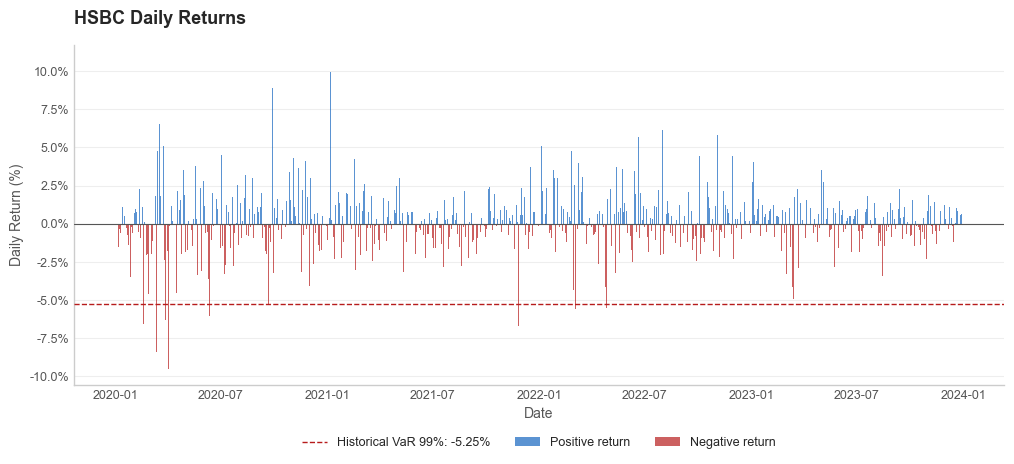

In [36]:
plot_daily_returns(returns)

In [37]:
def position_sizer(var_decimal, var_limit_gbp, current_price, proposed_shares=None):
    max_position_gbp = var_limit_gbp / abs(var_decimal)
    max_shares = int(max_position_gbp / current_price)
    
    print(f"VaR limit:          £{var_limit_gbp:,.2f}")
    print(f"Max position size:  £{max_position_gbp:,.2f}")
    print(f"Max shares:         {max_shares}")
    
    if proposed_shares is not None:
        proposed_value = proposed_shares * current_price
        proposed_var = proposed_value * abs(var_decimal)
        print(f"\nProposed shares:    {proposed_shares}")
        print(f"Proposed value:     £{proposed_value:,.2f}")
        print(f"Proposed VaR:       £{proposed_var:,.2f}")
        
        if proposed_shares > max_shares:
            print(f"\n⚠️  WARNING: Exceeds limit — reduce to {max_shares} shares")
        else:
            print(f"\n✅ Position is within your VaR limit")



In [38]:
current_price = data["Close"].squeeze().iloc[-1]

position_sizer(
    var_decimal=h_var,
    var_limit_gbp=300,
    current_price=current_price,
    proposed_shares=500
)

VaR limit:          £300.00
Max position size:  £5,717.87
Max shares:         9

Proposed shares:    500
Proposed value:     £317,162.72
Proposed VaR:       £16,640.59

⚠️  WARNING: Exceeds limit — reduce to 9 shares


In [39]:
from scipy.stats import t

def t_var(returns, confidence=0.99):
    nu, mu, sigma = t.fit(returns)
    return float(t.ppf(1 - confidence, nu, mu, sigma))

In [40]:
t_v = t_var(returns)

print(f"Portfolio value:    £{portfolio_value:,.2f}")
print(f"Historical 99%:     {h_var:.4f} → £{abs(h_var) * portfolio_value:,.2f}")
print(f"Parametric 99%:     {p_var:.4f} → £{abs(p_var) * portfolio_value:,.2f}")
print(f"T-distribution 99%: {t_v:.4f} → £{abs(t_v) * portfolio_value:,.2f}")
print(f"\nDegrees of freedom (ν): {t.fit(returns)[0]:.2f}")

Portfolio value:    £10,000.00
Historical 99%:     -0.0525 → £524.67
Parametric 99%:     -0.0441 → £440.60
T-distribution 99%: -0.0542 → £541.67

Degrees of freedom (ν): 3.20


In [41]:
def drawdown_analysis(returns, portfolio_value):
    cumulative = portfolio_value * (1 + returns).cumprod()
    running_max = cumulative.cummax()
    drawdown = (cumulative - running_max) / running_max
    max_dd = drawdown.min()
    
    print(f"Starting portfolio value:  £{portfolio_value:,.2f}")
    print(f"Final portfolio value:     £{cumulative.iloc[-1]:,.2f}")
    print(f"Maximum drawdown:          {max_dd:.2%}")
    print(f"Worst single day loss:     {returns.min():.2%}")
    
    return cumulative, drawdown

In [42]:
cumulative, drawdown = drawdown_analysis(returns, portfolio_value)

Starting portfolio value:  £10,000.00
Final portfolio value:     £10,694.63
Maximum drawdown:          -52.41%
Worst single day loss:     -9.52%


In [43]:
from scipy.stats import t as t_dist
import numpy as np

def monte_carlo_drawdown(returns, portfolio_value=10000, n_simulations=1000, n_days=252):
    nu, mu, sigma = t_dist.fit(returns)
    
    simulated_returns = t_dist.rvs(nu, mu, sigma, size=(n_days, n_simulations))
    
    cumulative_paths = portfolio_value * np.cumprod(1 + simulated_returns, axis=0)
    
    max_drawdowns = []
    for i in range(n_simulations):
        path = cumulative_paths[:, i]
        running_max = np.maximum.accumulate(path)
        drawdown = (path - running_max) / running_max
        max_drawdowns.append(drawdown.min())
    
    max_drawdowns = np.array(max_drawdowns)
    
    print(f"Monte Carlo Simulation — {n_simulations} paths, {n_days} days")
    print(f"─────────────────────────────────────────")
    print(f"Median max drawdown:           {np.percentile(max_drawdowns, 50):.2%}")
    print(f"95th percentile max drawdown:  {np.percentile(max_drawdowns, 5):.2%}")
    print(f"Worst simulated drawdown:      {max_drawdowns.min():.2%}")
    print(f"Probability of >20% drawdown:  {(max_drawdowns < -0.20).mean():.2%}")
    
    return max_drawdowns

In [44]:
max_drawdowns = monte_carlo_drawdown(returns, portfolio_value)

Monte Carlo Simulation — 1000 paths, 252 days
─────────────────────────────────────────
Median max drawdown:           -27.82%
95th percentile max drawdown:  -50.51%
Worst simulated drawdown:      -110.89%
Probability of >20% drawdown:  78.50%


In [45]:
def plot_return_distribution(returns, h_var, p_var, t_v):
    plt.style.use("seaborn-v0_8-whitegrid")
    fig, ax = plt.subplots(figsize=(12, 6))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    ax.hist(returns, bins=30, density=True, color="#CFE2F3", alpha=0.8, label="Actual returns", zorder=2)

    x = np.linspace(returns.min(), returns.max(), 1000)
    from scipy.stats import norm, t as t_dist
    nu, mu_t, sigma_t = t_dist.fit(returns)
    mu_n = returns.mean()
    sigma_n = returns.std()

    ax.plot(x, norm.pdf(x, mu_n, sigma_n), color="#1565C0", linewidth=1.5, label="Normal distribution", zorder=3)
    ax.plot(x, t_dist.pdf(x, nu, mu_t, sigma_t), color="#FF9800", linewidth=1.5, label=f"T-distribution (ν={nu:.2f})", zorder=3)

    ax.axvline(h_var, color="#B71C1C", linestyle="--", linewidth=1, label=f"Historical VaR 99%: {h_var:.2%}", zorder=4)
    ax.axvline(p_var, color="#1565C0", linestyle="--", linewidth=1, label=f"Parametric VaR 99%: {p_var:.2%}", zorder=4)
    ax.axvline(t_v, color="#FF9800", linestyle="--", linewidth=1, label=f"T-dist VaR 99%: {t_v:.2%}", zorder=4)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#CCCCCC")
    ax.spines["bottom"].set_color("#CCCCCC")

    ax.yaxis.grid(True, color="#EEEEEE", linewidth=0.8, zorder=0)
    ax.xaxis.grid(False)

    ax.set_title("HSBC Daily Return Distribution vs Fitted Models", 
                fontsize=13, fontweight="bold", pad=15, loc="left")
    ax.set_xlabel("Daily Return", fontsize=10, color="#555555")
    ax.set_ylabel("Density", fontsize=10, color="#555555")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1%}"))
    ax.tick_params(colors="#555555", labelsize=9)

    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), 
             ncol=3, framealpha=0, fontsize=9, edgecolor="none")

    plt.subplots_adjust(bottom=0.2)
    plt.show()

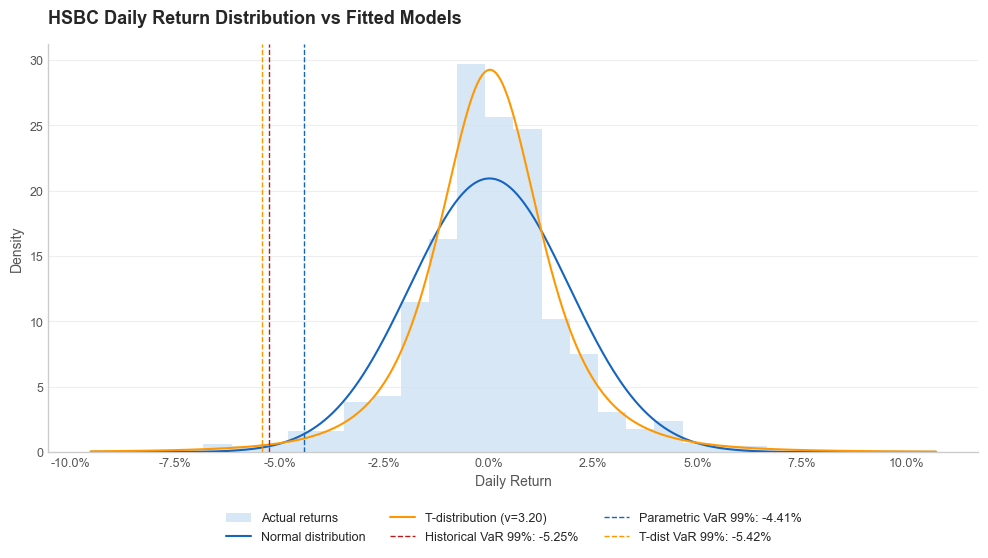

In [46]:
plot_return_distribution(returns, h_var, p_var, t_v)

In [47]:
def plot_pnl_drawdown(returns, portfolio_value=10000):
    cumulative = portfolio_value * (1 + returns).cumprod()
    running_max = cumulative.cummax()
    drawdown = (cumulative - running_max) / running_max

    plt.style.use("seaborn-v0_8-whitegrid")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    fig.patch.set_facecolor("white")
    ax1.set_facecolor("white")
    ax2.set_facecolor("white")

    ax1.plot(cumulative.index, cumulative, color="#1565C0", linewidth=1.2, label="Portfolio value", zorder=3)
    ax1.plot(cumulative.index, running_max, color="#888888", linewidth=0.8, linestyle="--", label="Peak value", zorder=2)
    ax1.fill_between(cumulative.index, cumulative, running_max, alpha=0.08, color="#1565C0", zorder=1)
    ax1.set_ylabel("Portfolio Value (£)", fontsize=10, color="#555555")
    ax1.set_title("HSBC Portfolio — Cumulative P&L and Drawdown", 
                 fontsize=13, fontweight="bold", pad=15, loc="left")
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"£{y:,.0f}"))
    ax1.margins(y=0.05)

    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)
    ax1.spines["bottom"].set_visible(False)
    ax1.spines["left"].set_color("#CCCCCC")
    ax1.yaxis.grid(True, color="#EEEEEE", linewidth=0.8, zorder=0)
    ax1.xaxis.grid(False)
    ax1.tick_params(colors="#555555", labelsize=9)
    ax1.legend(loc="upper left", framealpha=0, fontsize=9, edgecolor="none")

    ax2.fill_between(drawdown.index, drawdown, 0, color="#B71C1C", alpha=0.2, zorder=1)
    ax2.plot(drawdown.index, drawdown, color="#B71C1C", linewidth=1, label="Drawdown", zorder=2)
    ax2.axhline(drawdown.min(), color="#B71C1C", linestyle=":", linewidth=0.8, 
               label=f"Max drawdown: {drawdown.min():.2%}", zorder=3)
    ax2.set_ylabel("Drawdown (%)", fontsize=10, color="#555555")
    ax2.set_xlabel("Date", fontsize=10, color="#555555")
    ax2.set_ylim(drawdown.min() * 1.3, 0.01)
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)
    ax2.spines["left"].set_color("#CCCCCC")
    ax2.spines["bottom"].set_color("#CCCCCC")
    ax2.yaxis.grid(True, color="#EEEEEE", linewidth=0.8, zorder=0)
    ax2.xaxis.grid(False)
    ax2.tick_params(colors="#555555", labelsize=9)
    ax2.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), 
              ncol=2, framealpha=0, fontsize=9, edgecolor="none")

    plt.subplots_adjust(hspace=0.15, bottom=0.15)
    plt.show()

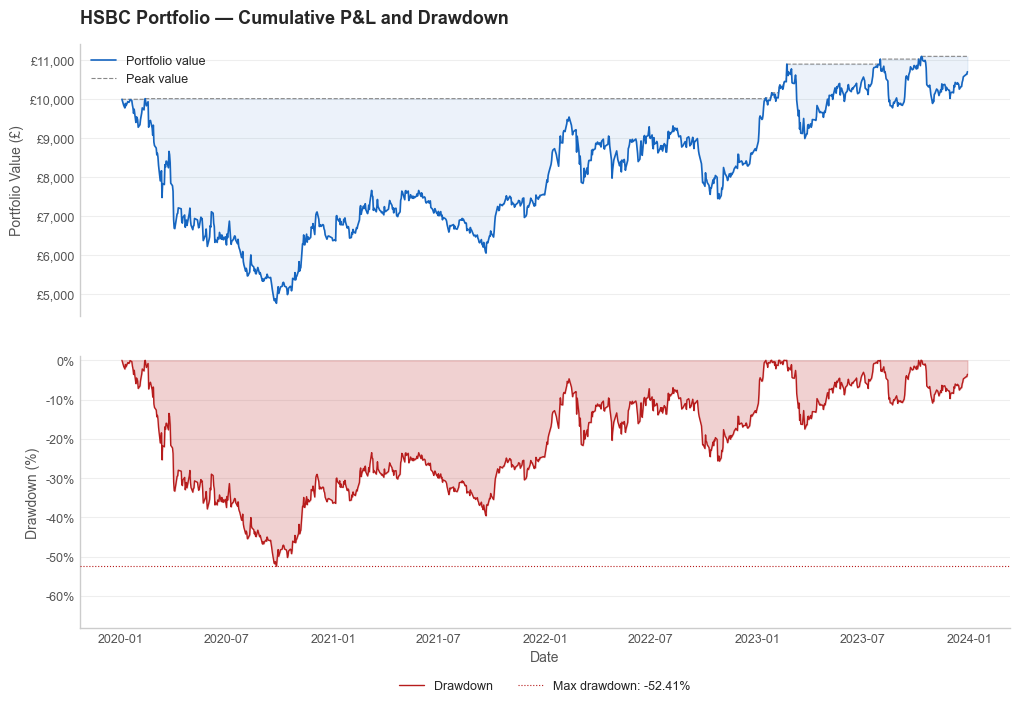

In [48]:
plot_pnl_drawdown(returns, portfolio_value)

In [49]:
def plot_monte_carlo(max_drawdowns, actual_drawdown):
    plt.style.use("seaborn-v0_8-whitegrid")
    fig, ax = plt.subplots(figsize=(12, 5))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    ax.hist(max_drawdowns, bins=50, color="#CFE2F3", edgecolor="#1565C0", 
            linewidth=0.3, density=True, label="Simulated max drawdowns", zorder=2)

    ax.axvline(np.percentile(max_drawdowns, 50), color="#1565C0", linewidth=1, 
               linestyle="--", label=f"Median: {np.percentile(max_drawdowns, 50):.2%}", zorder=4)
    ax.axvline(np.percentile(max_drawdowns, 5), color="#FF9800", linewidth=1, 
               linestyle="--", label=f"95th percentile: {np.percentile(max_drawdowns, 5):.2%}", zorder=4)
    ax.axvline(actual_drawdown, color="#B71C1C", linewidth=1.5, 
               linestyle="-", label=f"Actual max drawdown: {actual_drawdown:.2%}", zorder=4)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#CCCCCC")
    ax.spines["bottom"].set_color("#CCCCCC")
    ax.yaxis.grid(True, color="#EEEEEE", linewidth=0.8, zorder=0)
    ax.xaxis.grid(False)

    ax.set_title("Monte Carlo Simulation — Max Drawdown Distribution", 
                fontsize=13, fontweight="bold", pad=15, loc="left")
    ax.set_xlabel("Max Drawdown", fontsize=10, color="#555555")
    ax.set_ylabel("Density", fontsize=10, color="#555555")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
    ax.tick_params(colors="#555555", labelsize=9)

    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12),
             ncol=3, framealpha=0, fontsize=9, edgecolor="none")
    ax.invert_xaxis()
    plt.subplots_adjust(bottom=0.2)
    plt.show()

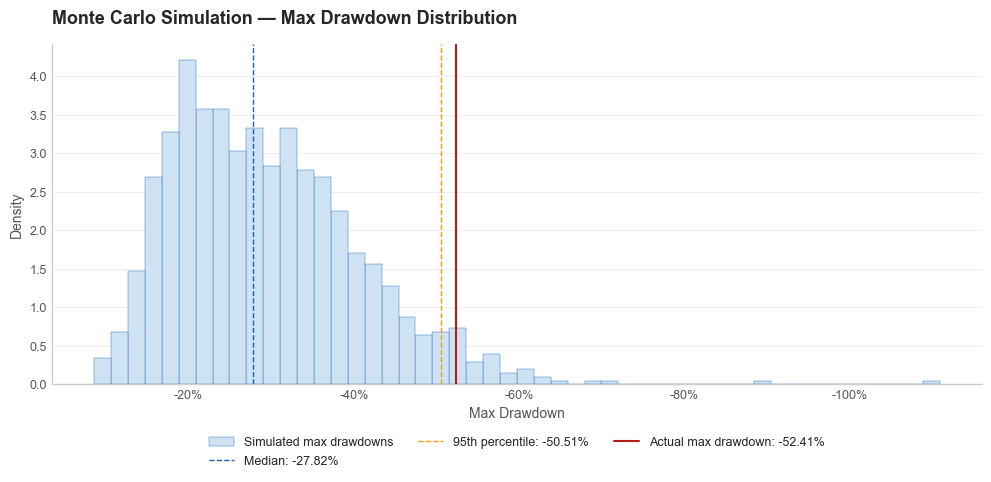

In [50]:
actual_max_drawdown = drawdown.min()
plot_monte_carlo(max_drawdowns, actual_max_drawdown)

In [51]:
from scipy.stats import binom

def backtest_var(returns, window=252, confidence=0.99):
    historical_violations = []
    t_violations = []
    historical_var_series = []
    t_var_series = []
    dates = []

    for i in range(window, len(returns)):
        window_returns = returns.iloc[i-window:i]
        actual_return = returns.iloc[i]
        
        h_var_rolling = historical_var(window_returns, confidence)
        t_var_rolling = t_var(window_returns, confidence)
        
        historical_var_series.append(h_var_rolling)
        t_var_series.append(t_var_rolling)
        dates.append(returns.index[i])
        
        historical_violations.append(1 if actual_return < h_var_rolling else 0)
        t_violations.append(1 if actual_return < t_var_rolling else 0)

    historical_var_series = pd.Series(historical_var_series, index=dates)
    t_var_series = pd.Series(t_var_series, index=dates)
    historical_violations = pd.Series(historical_violations, index=dates)
    t_violations = pd.Series(t_violations, index=dates)

    n = len(historical_violations)
    h_count = historical_violations.sum()
    t_count = t_violations.sum()
    expected = n * (1 - confidence)

    def kupiec_test(n, violations, confidence):
        p = 1 - confidence
        p_hat = violations / n
        if violations == 0:
            return 1.0
        lr = -2 * (violations * np.log(p/p_hat) + (n-violations) * np.log((1-p)/(1-p_hat)))
        from scipy.stats import chi2
        return chi2.sf(lr, df=1)

    def basel_zone(violations):
        if violations <= 4:
            return "🟢 Green — model accurate"
        elif violations <= 9:
            return "🟡 Yellow — model needs review"
        else:
            return "🔴 Red — model inaccurate"

    print(f"Backtest Results — {n} trading days tested")
    print(f"─────────────────────────────────────────────")
    print(f"Expected violations (99% VaR):  {expected:.1f}")
    print()
    print(f"Historical VaR:")
    print(f"  Violations:      {h_count} ({h_count/n:.2%})")
    print(f"  Basel zone:      {basel_zone(h_count)}")
    print(f"  Kupiec p-value:  {kupiec_test(n, h_count, confidence):.4f}")
    print()
    print(f"T-distribution VaR:")
    print(f"  Violations:      {t_count} ({t_count/n:.2%})")
    print(f"  Basel zone:      {basel_zone(t_count)}")
    print(f"  Kupiec p-value:  {kupiec_test(n, t_count, confidence):.4f}")

    return historical_var_series, t_var_series, historical_violations, t_violations

In [52]:
h_var_series, t_var_series, h_violations, t_violations = backtest_var(returns)

Backtest Results — 755 trading days tested
─────────────────────────────────────────────
Expected violations (99% VaR):  7.6

Historical VaR:
  Violations:      8 (1.06%)
  Basel zone:      🟡 Yellow — model needs review
  Kupiec p-value:  0.8705

T-distribution VaR:
  Violations:      8 (1.06%)
  Basel zone:      🟡 Yellow — model needs review
  Kupiec p-value:  0.8705


Both VaR models pass the Kupiec test at the 5% significance level with a p-value of 0.87, suggesting correct calibration. The Basel yellow zone classification is a mechanical artefact of the violation count threshold rather than evidence of model inadequacy. Over a 4-year period including COVID volatility, historical and t-distribution VaR converge because the sample already captures fat tail events — the t-distribution adds most value over shorter, calmer estimation windows.

In [53]:
def plot_backtest(returns, h_var_series, t_var_series, h_violations, t_violations):
    plt.style.use("seaborn-v0_8-whitegrid")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    fig.patch.set_facecolor("white")
    ax1.set_facecolor("white")
    ax2.set_facecolor("white")

    ax1.plot(returns[h_var_series.index], color="#8B949E", linewidth=0.8, 
             label="Actual returns", zorder=2)
    ax1.plot(h_var_series, color="#1565C0", linewidth=1, 
             linestyle="--", label="Historical VaR 99%", zorder=3)
    ax1.plot(t_var_series, color="#FF9800", linewidth=1, 
             linestyle="--", label="T-distribution VaR 99%", zorder=3)

    violation_dates = h_violations[h_violations == 1].index
    ax1.scatter(violation_dates, 
                returns[violation_dates],
                color="#B71C1C", s=50, zorder=4, label=f"Violations ({len(violation_dates)})")

    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)
    ax1.spines["left"].set_color("#CCCCCC")
    ax1.spines["bottom"].set_visible(False)
    ax1.yaxis.grid(True, color="#EEEEEE", linewidth=0.8, zorder=0)
    ax1.xaxis.grid(False)
    ax1.set_title("VaR Backtest — Actual Returns vs Rolling VaR", 
                 fontsize=13, fontweight="bold", pad=15, loc="left")
    ax1.set_ylabel("Daily Return", fontsize=10, color="#555555")
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1%}"))
    ax1.tick_params(colors="#555555", labelsize=9)
    ax1.margins(y=0.05)
    ax1.legend(loc="upper center", bbox_to_anchor=(0.5, -0.02),
              ncol=4, framealpha=0, fontsize=9, edgecolor="none")

    cumulative_violations = h_violations.cumsum()
    expected_line = pd.Series(
        [(i+1) * 0.01 for i in range(len(h_violations))],
        index=h_violations.index
    )

    ax2.plot(cumulative_violations, color="#1565C0", linewidth=1.5,
             label="Actual cumulative violations", zorder=3)
    ax2.plot(expected_line, color="#B71C1C", linewidth=1,
             linestyle="--", label="Expected (1% rate)", zorder=2)

    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)
    ax2.spines["left"].set_color("#CCCCCC")
    ax2.spines["bottom"].set_color("#CCCCCC")
    ax2.yaxis.grid(True, color="#EEEEEE", linewidth=0.8, zorder=0)
    ax2.xaxis.grid(False)
    ax2.set_ylabel("Cumulative violations", fontsize=10, color="#555555")
    ax2.set_xlabel("Date", fontsize=10, color="#555555")
    ax2.tick_params(colors="#555555", labelsize=9)
    ax2.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15),
              ncol=2, framealpha=0, fontsize=9, edgecolor="none")

    plt.subplots_adjust(hspace=0.15, bottom=0.15)
    plt.show()

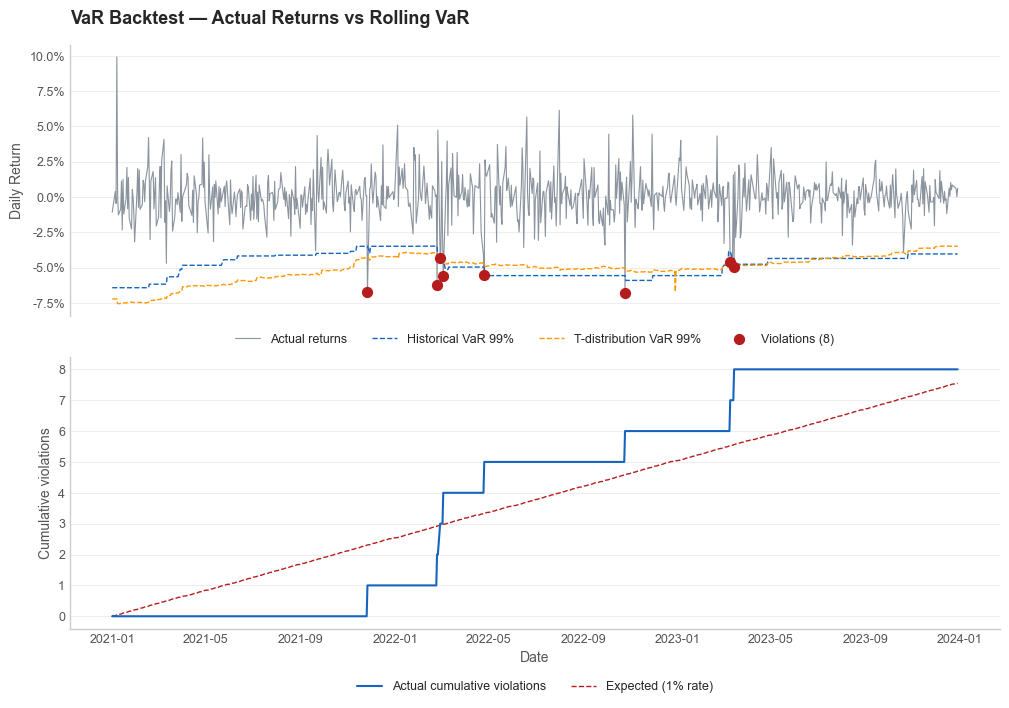

In [54]:
plot_backtest(returns, h_var_series, t_var_series, h_violations, t_violations)

While the overall violation rate of 1.06% is statistically consistent with a correctly calibrated 99% VaR model (Kupiec p-value = 0.87), the cumulative violation chart reveals clustering in 2022 — suggesting returns are not independently distributed during stress periods, violating a key assumption of both VaR models.

In [55]:
def stress_test(returns, portfolio_value=10000, position_size=None):
    scenarios = {
        "COVID Crash": ("2020-02-19", "2020-03-23"),
        "SVB Collapse": ("2023-03-08", "2023-03-24"),
        "Ukraine War": ("2022-02-24", "2022-03-15"),
        "Rate Hike Shock": ("2022-01-01", "2022-06-30")
    }

    results = {}

    print(f"Stress Test Results — Portfolio Value: £{portfolio_value:,.2f}")
    print(f"{'─' * 60}")

    for scenario_name, (start, end) in scenarios.items():
        scenario_returns = returns[start:end]

        if len(scenario_returns) == 0:
            print(f"\n{scenario_name}: No data available for this period")
            continue

        total_return = (1 + scenario_returns).prod() - 1
        worst_day = scenario_returns.min()
        best_day = scenario_returns.max()

        cumulative = portfolio_value * (1 + scenario_returns).cumprod()
        running_max = cumulative.cummax()
        drawdown = (cumulative - running_max) / running_max
        max_dd = drawdown.min()

        gbp_loss = total_return * portfolio_value
        worst_day_gbp = worst_day * portfolio_value

        scenario_var = historical_var(scenario_returns)
        var_breaches = (scenario_returns < scenario_var).sum()

        results[scenario_name] = {
            "total_return": total_return,
            "worst_day": worst_day,
            "max_drawdown": max_dd,
            "gbp_loss": gbp_loss,
            "var_breaches": var_breaches,
            "n_days": len(scenario_returns)
        }

        print(f"\n📊 {scenario_name} ({start} to {end})")
        print(f"   Trading days:        {len(scenario_returns)}")
        print(f"   Total return:        {total_return:.2%}")
        print(f"   £ P&L:               £{gbp_loss:,.2f}")
        print(f"   Worst single day:    {worst_day:.2%} (£{worst_day_gbp:,.2f})")
        print(f"   Max drawdown:        {max_dd:.2%}")
        print(f"   VaR breaches:        {var_breaches} of {len(scenario_returns)} days")
        print(f"   {'⚠️  Severe stress' if total_return < -0.15 else '📉 Moderate stress' if total_return < -0.05 else '➡️  Mild stress'}")

    return results

In [56]:
stress_results = stress_test(returns, portfolio_value)

Stress Test Results — Portfolio Value: £10,000.00
────────────────────────────────────────────────────────────

📊 COVID Crash (2020-02-19 to 2020-03-23)
   Trading days:        24
   Total return:        -11.22%
   £ P&L:               £-1,121.58
   Worst single day:    -8.42% (£-842.43)
   Max drawdown:        -20.92%
   VaR breaches:        1 of 24 days
   📉 Moderate stress

📊 SVB Collapse (2023-03-08 to 2023-03-24)
   Trading days:        13
   Total return:        -14.46%
   £ P&L:               £-1,446.42
   Worst single day:    -4.96% (£-495.67)
   Max drawdown:        -15.33%
   VaR breaches:        1 of 13 days
   📉 Moderate stress

📊 Ukraine War (2022-02-24 to 2022-03-15)
   Trading days:        14
   Total return:        -12.42%
   £ P&L:               £-1,241.59
   Worst single day:    -6.22% (£-622.49)
   Max drawdown:        -13.37%
   VaR breaches:        1 of 14 days
   📉 Moderate stress

📊 Rate Hike Shock (2022-01-01 to 2022-06-30)
   Trading days:        123
   Total r

In [ ]:
def plot_stress_test(returns, portfolio_value=10000):
    scenarios = {
        "COVID Crash": ("2020-02-19", "2020-03-23"),
        "SVB Collapse": ("2023-03-08", "2023-03-24"),
        "Ukraine War": ("2022-02-24", "2022-03-15"),
        "Rate Hike Shock": ("2022-01-01", "2022-06-30")
    }

    colors = {
        "COVID Crash": "#B71C1C",
        "SVB Collapse": "#E65100",
        "Ukraine War": "#F57F17",
        "Rate Hike Shock": "#1565C0"
    }

    plt.style.use("seaborn-v0_8-whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.patch.set_facecolor("white")
    axes = axes.flatten()

    for idx, (scenario_name, (start, end)) in enumerate(scenarios.items()):
        ax = axes[idx]
        ax.set_facecolor("white")

        scenario_returns = returns[start:end]
        if len(scenario_returns) == 0:
            ax.text(0.5, 0.5, "No data available",
                   transform=ax.transAxes,
                   ha="center", va="center",
                   color="#555555", fontsize=10)
            ax.set_title(scenario_name, fontsize=11,
                        fontweight="bold", loc="left")
            continue

        cumulative = portfolio_value * (1 + scenario_returns).cumprod()
        total_return = (1 + scenario_returns).prod() - 1
        color = colors[scenario_name]
        start_value = cumulative.iloc[0]

        ax.plot(cumulative.index, cumulative, color=color,
               linewidth=1.5, zorder=3)
        ax.fill_between(cumulative.index, cumulative, start_value,
                       color=color, alpha=0.15, zorder=2)
        ax.axhline(start_value, color="#888888", linewidth=0.8,
                  linestyle="--", zorder=1)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_color("#CCCCCC")
        ax.spines["bottom"].set_color("#CCCCCC")
        ax.yaxis.grid(True, color="#EEEEEE", linewidth=0.8, zorder=0)
        ax.xaxis.grid(False)

        pnl_color = "#B71C1C" if total_return < 0 else "#1565C0"
        ax.set_title(f"{scenario_name}   {total_return:+.2%}",
                    fontsize=11, fontweight="bold",
                    loc="left", color=pnl_color)
        ax.set_ylabel("Portfolio Value (£)", fontsize=9, color="#555555")
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"£{y:,.0f}"))
        ax.xaxis.set_major_locator(plt.MaxNLocator(6))
        ax.tick_params(colors="#555555", labelsize=8)
        ax.tick_params(axis="x", rotation=30)
        ax.margins(y=0.1)

    fig.suptitle("Stress Test — Portfolio Performance During Crisis Periods",
                fontsize=13, fontweight="bold", x=0.02, ha="left", y=1.01)

    plt.tight_layout(pad=2.0)
    plt.show()

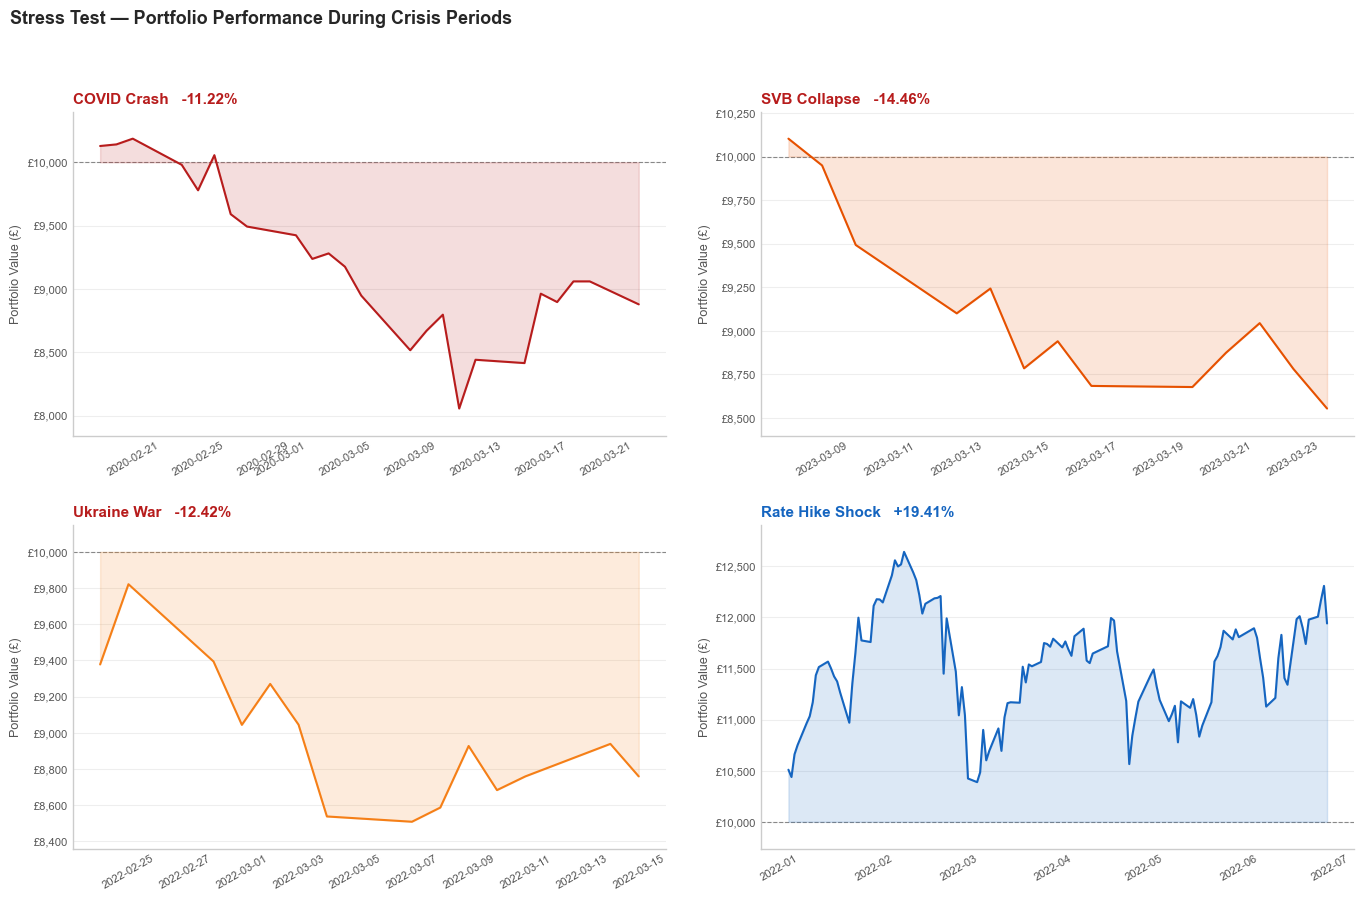

In [61]:
plot_stress_test(returns, portfolio_value)